# Image Classification with PyTorch

## Goal
Use PyTorch to build and train a CNN on a real image dataset.
Move from numpy scratch implementation to production-ready framework.

## Dataset
MNIST — 70,000 handwritten digit images (0-9)
28x28 grayscale — perfect for learning CNN classification.

## What We Build
CNN with PyTorch: Conv → ReLU → MaxPool → Conv → ReLU → MaxPool → FC → Output

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")

Device: mps
PyTorch version: 2.12.0


## 1. Load MNIST Dataset

In [2]:
# Define transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # MNIST mean and std
])

# Download and load
train_dataset = datasets.MNIST(
    root="../data/raw",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="../data/raw",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Image shape: {train_dataset[0][0].shape}")
print(f"Classes: {train_dataset.classes}")

Training samples: 60000
Test samples: 10000
Image shape: torch.Size([1, 28, 28])
Classes: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


## 2. Visualize Sample Images

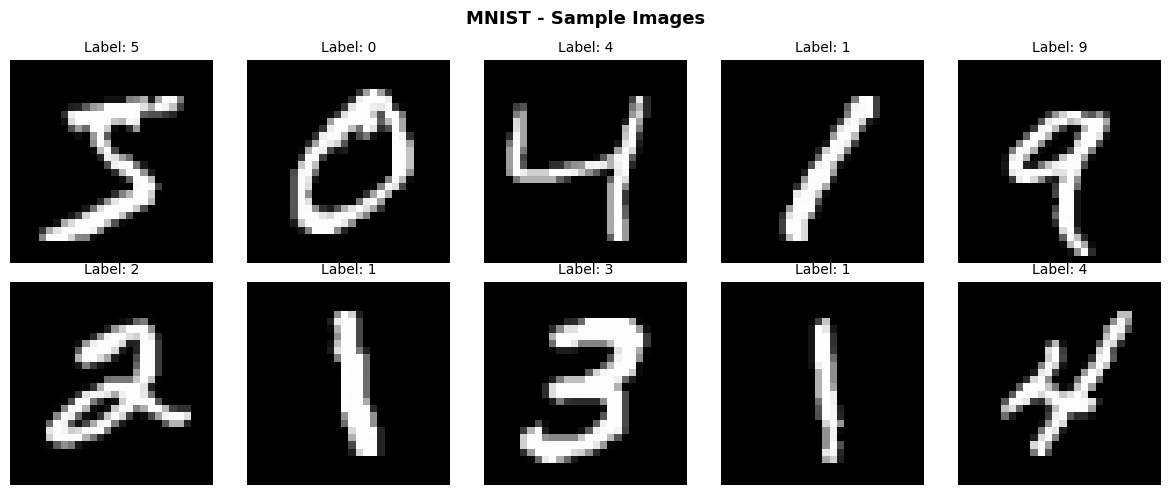

In [3]:
# Show sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"Label: {label}", fontsize=10)
    ax.axis("off")

plt.suptitle("MNIST - Sample Images", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("mnist_samples.png", dpi=300)
plt.show()

## 3. Difine CNN Architecture

In [4]:
import torch.nn.functional as F

class MNISTNet(nn.Module):
    """
    CNN for MNIST digit classification.
    Architecture: Conv(32) → ReLU → Pool → Conv(64) → ReLU → Pool → FC(128) → FC(10)
    """

    def __init__(self):
        super(MNISTNet, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forweard(self, x):
        x = self.pool(torch.relu(self.conv1(x)))  # 28x28 -> 14x14
        x = self.pool(torch.relu(self.conv2(x)))  # 14x14 -> 7x7
        x = self.dropout(x)
        x = x.view(-1, 64 * 7 * 7)                # Flatten
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x


model = MNISTNet().to(device)
total_params = sum(p.numel() for p in model.parameters())

print(f"Model architecture:")
print(model)
print(f"\nTotal parameters: {total_params:,}")

Model architecture:
MNISTNet(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Total parameters: 421,642


## 4. Train the Model

In [6]:
import torch.nn.functional as F

class MNISTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.dropout(x)
        x = x.view(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = MNISTNet().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 421,642


In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / len(loader), correct / total


EPOCHS = 5
train_losses, train_accs = [], []
test_losses, test_accs = [], []

print("Training...")
for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
    te_loss, te_acc = evaluate(model, test_loader, criterion)
    train_losses.append(tr_loss)
    train_accs.append(tr_acc)
    test_losses.append(te_loss)
    test_accs.append(te_acc)
    print(f"Epoch {epoch+1}/{EPOCHS} — Train: {tr_acc:.1%} | Test: {te_acc:.1%}")

print(f"\nFinal Test Accuracy: {test_accs[-1]:.1%}")

Training...
Epoch 1/5 — Train: 99.6% | Test: 99.3%
Epoch 2/5 — Train: 99.7% | Test: 99.2%
Epoch 3/5 — Train: 99.7% | Test: 99.2%
Epoch 4/5 — Train: 99.8% | Test: 99.2%
Epoch 5/5 — Train: 99.7% | Test: 99.3%

Final Test Accuracy: 99.3%


## 5. Visualize Results

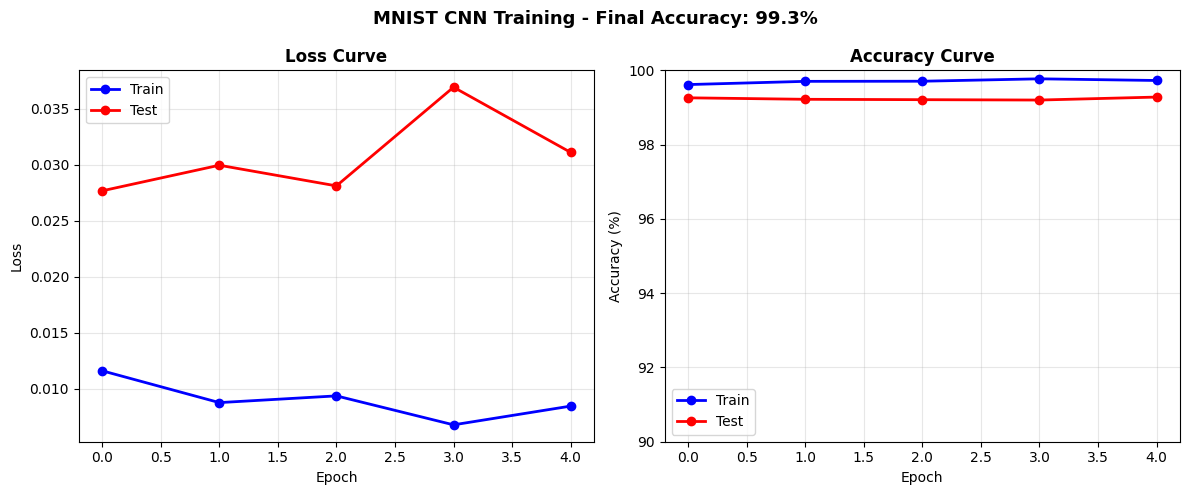

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(train_losses, "b-o", label="Train", linewidth=2)
axes[0].plot(test_losses, "r-o", label="Test", linewidth=2)
axes[0].set_title("Loss Curve", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot([a*100 for a in train_accs], "b-o", label="Train", linewidth=2)
axes[1].plot([a*100 for a in test_accs], "r-o", label="Test", linewidth=2)
axes[1].set_title("Accuracy Curve", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_ylim(90, 100)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("MNIST CNN Training - Final Accuracy: 99.3%",
            fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("mnist_training.png", dpi=300)
plt.show()